## Digit Recognizer Using MNIST Dataset

##### Libraries and modules to be imported below

In [25]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets 
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform = transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)



In [6]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [ ]:
iterator = iter(train_loader)
image, label = next(iterator)
print("First batch of image: ", image.shape, label.shape)

First batch of image:  torch.Size([128, 1, 28, 28]) torch.Size([128])


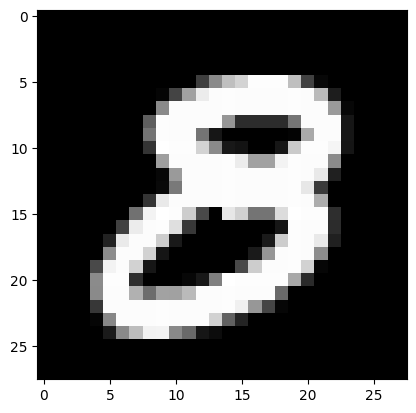

In [21]:
plt.imshow(image[0].squeeze(), cmap="gray")
plt.show()

In [22]:
print(image[0], label[0])

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [26]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Linear(28*28, 256)
        self.second = nn.Linear(256, 128)
        self.third = nn.Linear(128, 64)
        self.fourth = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.first(x))
        x = self.dropout(x)
        x = self.relu(self.second(x))
        x = self.dropout(x)
        x = self.relu(self.third(x))
        x = self.dropout(x)
        x = self.fourth(x)

        return x

model = Classifier()
print(model)

Classifier(
  (first): Linear(in_features=784, out_features=256, bias=True)
  (second): Linear(in_features=256, out_features=128, bias=True)
  (third): Linear(in_features=128, out_features=64, bias=True)
  (fourth): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)
